# 01 · Acquisition overview

What is on disk, how big it is, under what licence, and whether it matches the
**Verified** figures in [`docs/data/data-catalog.md`](../docs/data/data-catalog.md).

Regenerate the two inputs before running this notebook:

```bash
uv run python -m candidate_screener.data.verify  --all
uv run python -m candidate_screener.data.profile --all
```

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from candidate_screener.config import DOCS_DATA, RAW, MANIFEST, PROFILE_METRICS
from candidate_screener.data.profile import load_split
from candidate_screener.data.sources import SOURCES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

METRICS = json.loads(PROFILE_METRICS.read_text())["checks"]
print("profile metrics generated:", json.loads(PROFILE_METRICS.read_text())["generated"])

profile metrics generated: 2026-08-19T11:44:13+00:00


## Registry — every source evaluated, including the rejected ones

In [2]:
registry = pd.DataFrame([{
    "key": s.key, "catalog": s.catalog_id, "tier": s.tier, "adopted": s.adopted,
    "licence": s.licence, "automated": s.automated, "role": s.role,
} for s in SOURCES.values()]).sort_values(["catalog", "key"])
registry

,key,catalog,tier,adopted,licence,automated,role
0,fit,A1,1,True,None declared (accepted — decision D7),True,Core benchmark for Stages 1–4; substrate for the synthetic retrieval pools
2,djinni-cv,A2,1,True,MIT,True,In-domain candidate CVs; joins to the JD side on `Primary Keyword`
1,djinni-jd,A2,1,True,MIT,True,In-domain IT job descriptions for the end-to-end evaluation set
3,ats,A4,3,False,Apache-2.0,True,REJECTED — 97.2% derivative of A1; documented `[SEP]` separator absent; circular score
4,dataturks,B1,2,True,None declared,True,Resume-native NER gold seed (decision D5); de-identify before use
5,skillspan,B2,1,True,CC-BY-4.0,True,Primary skill/knowledge span supervision — the volume DataTurks lacks
6,green,B3,2,True,CC-BY-4.0,True,Supplementary span supervision; adopt only if B2 proves insufficient
7,livecareer-pdf,C1,1,True,"Kaggle-hosted, publisher terms",False,The only source of real PDFs — satisfies §5.2's parsing/robustness claims (decision D6)
8,livecareer,C2,1,True,None declared,True,Same corpus as C1 without the PDFs — `Resume_html` still exercises real markup parsing
9,resume-atlas,C3,2,True,MIT,True,Clustering EDA only (R7)


## What was actually downloaded

In [3]:
manifest = json.loads(MANIFEST.read_text())
rows = []
for key, rec in manifest["sources"].items():
    rows.append({
        "key": key, "catalog": rec["catalog_id"], "tier": rec["tier"],
        "files": sum(a["files"] for a in rec["artifacts"]),
        "MB": round(rec.get("bytes", 0) / 1e6, 1),
        "rows": sum(a["rows"] or 0 for a in rec["artifacts"]),
        "problems": len(rec["problems"]),
        "licence": rec["licence"],
    })
acquired = pd.DataFrame(rows).sort_values("MB", ascending=False)
print(f"total {manifest['total_bytes'] / 1e6:.0f} MB, verified {manifest['generated']}")
acquired

total 676 MB, verified 2026-08-19T11:41:36+00:00


,key,catalog,tier,files,MB,rows,problems,licence
2,djinni-cv,A2,1,1,237.4,210250,0,MIT
1,djinni-jd,A2,1,1,145.9,141897,0,MIT
6,livecareer-pdf,C1,1,2485,118.3,2484,0,"Kaggle-hosted, publisher terms"
10,data-jobs,D2,2,1,75.3,785741,0,Apache-2.0
9,esco,D1,1,3,40.3,143054,0,European Commission ESCO terms of use
8,resume-atlas,C3,2,1,23.6,13389,0,MIT
7,livecareer,C2,1,1,20.0,2484,0,None declared
0,fit,A1,1,2,12.3,8000,0,None declared (accepted — decision D7)
3,dataturks,B1,2,2,1.2,220,0,None declared
5,green,B3,2,3,1.1,9968,0,CC-BY-4.0


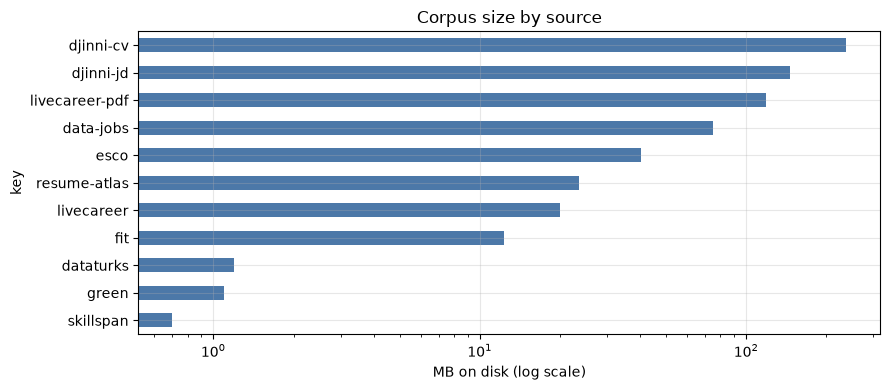

In [4]:
ax = acquired.set_index("key")["MB"].sort_values().plot.barh(
    logx=True, color="#4C78A8")
ax.set_xlabel("MB on disk (log scale)")
ax.set_title("Corpus size by source")
plt.tight_layout()

Size is not usefulness. The two Djinni tables are 57% of the bytes but carry **no fit
labels**; the 12 MB core benchmark carries every label the matching progression is
trained and scored on.

## Licence and PII posture — what may be redistributed, and what must be de-identified

In [5]:
posture = pd.DataFrame([{
    "catalog": s.catalog_id, "key": s.key, "licence": s.licence, "PII": s.pii,
} for s in SOURCES.values() if s.adopted]).sort_values("catalog")
posture.style.set_properties(**{"text-align": "left"})

,catalog,key,licence,PII
0,A1,fit,None declared (accepted — decision D7),"Livecareer-style resumes; names largely stripped, employers/schools remain"
1,A2,djinni-jd,MIT,Pre-anonymized by the publishers
2,A2,djinni-cv,MIT,Pre-anonymized by the publishers
3,B1,dataturks,None declared,"DIRECT — `Name` and `Email Address` are annotated classes, plus residual emails/phones"
4,B2,skillspan,CC-BY-4.0,Pre-anonymized (entities replaced with placeholders)
5,B3,green,CC-BY-4.0,Pre-anonymized
6,C1,livecareer-pdf,"Kaggle-hosted, publisher terms",Livecareer-style resumes; treat as personal data even though names are largely stripped
7,C2,livecareer,None declared,As C1
8,C3,resume-atlas,MIT,Pre-normalised text; no direct identifiers observed
9,D1,esco,European Commission ESCO terms of use,None


Two sources need care before anything derived from them is committed or shown:

- **B1 DataTurks** — `Name` and `Email Address` are *annotated entity classes*, so the PII
  is not incidental, it is the label set. De-identify during BIO conversion (action plan §3.1).
- **D1 ESCO** — EU terms of use; redistribution of derived vocabulary extracts is open
  question **Q11**.

## Effective sample size — the number that governs every confidence interval

In [6]:
fit = METRICS["fit"]
eff = pd.DataFrame({
    split: {"pairs (rows)": m["rows"], "unique resumes": m["unique_resumes"],
            "unique JDs": m["unique_jds"], "JDs with >=1 Good Fit": m["jds_with_good_fit"]}
    for split, m in fit["splits"].items()})
eff

,train,test
pairs (rows),6241,1759
unique resumes,642,477
unique JDs,280,71
JDs with >=1 Good Fit,115,28


8,000 rows is a near-complete cross-product of ~640 resumes and ~280 JDs. Every metric's
error bar must be computed against the document counts, not the row count — this is the
evidence behind decision **D2** (targets rebased as deltas on the measured baseline).

Next: [`02-fit-benchmark-eda.ipynb`](02-fit-benchmark-eda.ipynb).